In [18]:
%load_ext dotenv
%dotenv
%load_ext mypy_ipython

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv
The mypy_ipython extension is already loaded. To reload it, use:
  %reload_ext mypy_ipython


In [19]:
from langgraph.graph import START, END, StateGraph,add_messages,MessagesState
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage ,AIMessage , RemoveMessage
from collections.abc import Sequence
from typing import Literal ,Annotated

In [20]:
chat = ChatOpenAI(
    model = 'gpt-4o',
    seed = 365,
    temperature = 0.9,
    max_tokens=500
)

In [21]:
##
# Example How this Remove Messages will Work
# #

my_list = add_messages(
    [
        AIMessage("What is your question?"),
        HumanMessage("Could you tell me a grook by Piet Hein?"),
        AIMessage("Certainly! Here's a well-known grook by Piet Hein..."),
        AIMessage("Would you like to ask one more question?"),
        HumanMessage("yes"),
        AIMessage("What is your question?"),
        HumanMessage("Where was the poet born?"),
        AIMessage("Piet Hein was born in Copenhagen, Denmark, on December 16, 1905."),
        AIMessage("Would you like to ask one more question?")],
    [
        HumanMessage("yes")
    ]
)

remove_list = [RemoveMessage(id = i.id) for i in my_list[:-5]]

print(remove_list)

add_messages(my_list, remove_list)

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='3d6a5ef5-41dc-4f18-a5b7-fe11ac845d96'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='e30ef34f-91c3-4ade-bf56-34a012f3c70c'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='91006c4d-591f-4e39-8d5c-b0fe005c7cc6'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='90f8e6c5-7eee-475b-b19e-6bfaecc17466'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='82ffa7d4-c632-4fbd-9b39-1ddcacbfac7c')]


[AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='6e94c125-dd12-400c-82cf-b8104009a176', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Where was the poet born?', additional_kwargs={}, response_metadata={}, id='7decc2cd-4010-4564-842a-c54febde2452'),
 AIMessage(content='Piet Hein was born in Copenhagen, Denmark, on December 16, 1905.', additional_kwargs={}, response_metadata={}, id='1eca382f-1fd6-4091-a1ff-e9a13fb0edb8', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='Would you like to ask one more question?', additional_kwargs={}, response_metadata={}, id='cf62010e-c017-4e82-8726-4fa60edd9a42', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='1d11426c-f903-4b27-b008-ea4522eddcaf')]

In [22]:
#class State(TypedDict):
#   message: Annotated[Sequence[BaseMessage] , add_messages]

##
# No Longer State need to Managaed Manually we can do using MessagesState from Lanchain
# #

In [23]:
def ask_question(state : MessagesState) -> MessagesState:
    print(f'\n---------------ask_question Started')
    print('What is your Question?')
    for i in state['messages']:
        i.pretty_print()

    question = 'What is your Question?'
    print(question)

    return  MessagesState(
        messages = [AIMessage(content=question),HumanMessage(content=input())]
    )

In [24]:
def remove_message(state: MessagesState) -> MessagesState:
    print(f'\n---------------remove_message Started')
    remove_messages = [
        RemoveMessage(id=i.id)
        for i in state['messages'][:-5]
    ]
    return MessagesState(messages=remove_messages)

In [25]:
def chat_bot(state : MessagesState) -> MessagesState:
    print(f'\n---------------chat_bot Started')
    response = chat.invoke(
        state['messages']
    )

    for i in state['messages']:
        i.pretty_print()

    response.pretty_print()
    return MessagesState(
        messages = [response]
    )

In [26]:
def ask_another_question(state: MessagesState) -> MessagesState:
    print(f"\n-------> ENTERING ask_another_question:")
    question = "Would you like to ask one more question (yes/no)?"
    for i in state['messages']:
        i.pretty_print()
    print(question)

    return MessagesState(
        messages = [AIMessage(content=question),HumanMessage(content=input())]
    )

In [27]:
def route_function(state: MessagesState) -> Literal['remove_message', END]:
    # -1 Brings the last Value
    answer = state["messages"][-1].content.lower().strip()
    if answer == 'yes':
        return 'remove_message'
    return END

##Build Graph

In [28]:
graph = StateGraph(MessagesState)

In [29]:
graph.add_node("ask_question", ask_question)
graph.add_node("chat_bot", chat_bot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("remove_message", remove_message)

In [30]:
graph.add_edge( START,"ask_question")
graph.add_edge("ask_question","chat_bot")
graph.add_edge("chat_bot","ask_another_question")
graph.add_edge("remove_message","ask_another_question")

graph.add_conditional_edges(
    source="ask_another_question",
    path=route_function
)

In [31]:
graph_compiled = graph.compile()

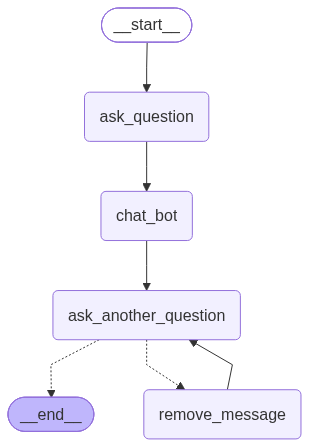

In [32]:
graph_compiled

In [33]:
graph_compiled.invoke(
    MessagesState(messages=[])
)


---------------ask_question Started
What is your Question?
What is your Question?


KeyboardInterrupt: Interrupted by user